# ATF Case: Multi-Electron Trajectory Tracking

This notebook analyzes an ATF-relevant CO$_2$ laser wakefield case with the following plasma and laser parameters:

$$
n_e = 2 \times 10^{16}\ \mathrm{cm}^{-3}, \qquad
\lambda_0 = 9.2\ \mu\mathrm{m}, \qquad
w_0 = 75\ \mu\mathrm{m},
$$

$$
a_0 = 3.26, \qquad
\tau = 500\ \mathrm{fs}.
$$

In normalized plasma units, this corresponds to

$$
k_p w_0 = 1.99, \qquad
k_p c \tau = 3.98.
$$

This notebook tracks multiple test-electron trajectories in the wakefield generated by this ATF parameter set. It creates separate one-electron input files with different initial transverse positions, runs them using the multi-core processing capability of a personal computer, and then loads the resulting debug trajectory files for comparison and visualization. A simpler single-electron version of this analysis is available in the `ATF2e16_single_track` notebook in the same folder.

In [8]:
from pathlib import Path
import os
import sys

project_root = Path.cwd().resolve()
core_name = "ATF2e16"

while not (project_root / "main.py").exists():
    if project_root == project_root.parent:
        raise RuntimeError("Could not find QuEP project root containing main.py.")
    project_root = project_root.parent

os.chdir(project_root)

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print("Working directory set to:", project_root)
print("Core Project name:", core_name)

Working directory set to: /Users/navidv/GitHub/QuEP
Core Project name: ATF2e16


In [27]:
# Create multiple one-electron input files for parallel debug runs.

from pathlib import Path

# Choose the five starting heights here, in c/omega_p.
# Keep x_c and xi_c fixed, and scan y_c.
particle_inputs = [
    {"tag": "p00", "x_c": 0.1, "y_c": 0.0, "xi_c": 6},
    {"tag": "p01", "x_c": 0.5, "y_c": 0.0, "xi_c": 6},
    {"tag": "p02", "x_c": 1.0, "y_c": 0, "xi_c": 6},
    {"tag": "p03", "x_c": 1.5, "y_c": 0, "xi_c": 6},
    {"tag": "p04", "x_c": 2.0, "y_c": 0, "xi_c": 6},
    {"tag": "p05", "x_c": 2.5, "y_c": 0, "xi_c": 6},
]

input_template = """# Auto-generated by {core_name} multiprocessing notebook.

simulation_name = "QUASI3D"
shape = "single"
iterations = 400000
mode = -1

# IMPORTANT: unique fname gives each run a unique output/debug file.
fname = "{core_name}_{tag}.npz"
debugmode = True

# Probe initial coordinates, in c/omega_p.
x_c = {x_c:.12g}
y_c = {y_c:.12g}
xi_c = {xi_c:.12g}

# Initial momentum.
px_0 = 0
py_0 = 0
pz_0 = 0

# Screen distances from z-axis of plasma cell, in mm.
x_s = [10, 50, 100, 250, 500]

# Shape parameters.
s1 = 1  # in y
s2 = 1  # in xi

# Densities: single electron.
ydensity = 1
xidensity = 1
xdensity = 1
resolution = None

# Quasi3D simulation parameters.
quasi_id = "000026"
quasi_data_dir = "data/OSIRIS/{core_name}"
quasi_density = 2e22
quasi_propagation_speed = 1.0
dt_safety_factor = 0.1
"""

input_modules = []

for particle in particle_inputs:
    tag = particle["tag"]
    module_name = f"{core_name}_{tag}"

    input_modules.append(f"input.{module_name}")

    path = project_root / "input" / f"{module_name}.py"

    values = {
        "core_name": core_name,
        **particle,
    }

    with open(path, "w") as f:
        f.write(input_template.format(**values))

    print(
        f"Wrote {path} with y_c={particle['y_c']} "
        f"-> data/{core_name}_{tag}-DEBUG.obj"
    )

print("\nInput modules to run:")
for module in input_modules:
    print("  ", module)

Wrote /Users/navidv/GitHub/QuEP/input/ATF2e16_p00.py with y_c=0.0 -> data/ATF2e16_p00-DEBUG.obj
Wrote /Users/navidv/GitHub/QuEP/input/ATF2e16_p01.py with y_c=0.0 -> data/ATF2e16_p01-DEBUG.obj
Wrote /Users/navidv/GitHub/QuEP/input/ATF2e16_p02.py with y_c=0 -> data/ATF2e16_p02-DEBUG.obj
Wrote /Users/navidv/GitHub/QuEP/input/ATF2e16_p03.py with y_c=0 -> data/ATF2e16_p03-DEBUG.obj
Wrote /Users/navidv/GitHub/QuEP/input/ATF2e16_p04.py with y_c=0 -> data/ATF2e16_p04-DEBUG.obj
Wrote /Users/navidv/GitHub/QuEP/input/ATF2e16_p05.py with y_c=0 -> data/ATF2e16_p05-DEBUG.obj

Input modules to run:
   input.ATF2e16_p00
   input.ATF2e16_p01
   input.ATF2e16_p02
   input.ATF2e16_p03
   input.ATF2e16_p04
   input.ATF2e16_p05


### Run the particles in parallel
The following code needs to be run from a terminal or from and IDE like VSCode. If you run this inside Jupyter Notebook, it might crash because Jupyter does play nice with multi-core processes. 

```
from include.parallel_case_runner_pc import run_debug_cases

run_debug_cases(
    core_name="ATF2e16",
    max_parallel=8,
)
```

**Note:** number_of_files may exceed max_parallel. The runner will only keep up to max_parallel jobs active at a time; when one job finishes, the next file in the list is started.

In [28]:
#Automatically detect the multi-track files and load them
import gc
import importlib
import pickle
import re
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

# Clean up memory from earlier notebook cells.
gc.collect()

project_root = Path.cwd()

print("Working directory set to:", project_root)

# -----------------------------------------------------------------------------
# Find all completed debug trajectory files for this case.
#
# This looks for files like:
#     data/ATF2e16_p00-DEBUG.obj
#     data/ATF2e16_p01-DEBUG.obj
#     ...
#
# The number of files is determined automatically from the files found in data/.
# -----------------------------------------------------------------------------
data_dir = project_root / "data"

pattern = re.compile(rf"^{re.escape(core_name)}_(p\d+)-DEBUG\.obj$")

debug_files = []

for path in data_dir.glob(f"{core_name}_p*-DEBUG.obj"):
    match = pattern.match(path.name)

    if match:
        tag = match.group(1)
        debug_files.append((tag, path))

debug_files = sorted(debug_files, key=lambda item: int(item[0][1:]))

if not debug_files:
    raise FileNotFoundError(
        f"No completed debug files found matching "
        f"{data_dir}/{core_name}_p*-DEBUG.obj"
    )

debug_tags = [tag for tag, path in debug_files]

print("Found completed debug tags:")
print(debug_tags)

# -----------------------------------------------------------------------------
# Load one representative input file to configure the Quasi3D field infrastructure.
#
# The fields are the same for all particles; only x_c/y_c/xi_c and fname differ.
# Use the first completed debug tag as the representative case.
# -----------------------------------------------------------------------------
representative_tag = debug_tags[0]
input_module = f"input.{core_name}_{representative_tag}"

importlib.invalidate_caches()
sys.modules.pop(input_module, None)

init = importlib.import_module(input_module)

import include.simulations.useQuasi3D as sim
sim.configure(init)

# -----------------------------------------------------------------------------
# Load all completed debug trajectory objects.
#
# Each input fname is expected to be:
#     <core_name>_pXX.npz
#
# so main.py should save:
#     data/<core_name>_pXX-DEBUG.obj
# -----------------------------------------------------------------------------
debugs = []

def load_debug_object(path):
    with open(path, "rb") as file:
        loaded = pickle.load(file)

    # main.py often saves Debug as a one-element list/tuple in this tutorial case.
    return loaded[0] if isinstance(loaded, (list, tuple)) else loaded


for tag, debug_file in debug_files:
    debug = load_debug_object(debug_file)
    debug.tag = tag
    debug.source_file = debug_file
    debugs.append(debug)

    print(f"Loaded {tag}: {debug_file}")

print(f"\nLoaded input module for fields: {init.__name__}")
print(f"Loaded {len(debugs)} debug trajectories.")

print("\nThe first Debug object contains:")
for key, value in debugs[0].__dict__.items():
    if key not in ["tag", "source_file"]:
        print(f"{key:20s}  type={type(value).__name__:15s}  shape={np.shape(value)}")

Working directory set to: /Users/navidv/GitHub/QuEP
Found completed debug tags:
['p00', 'p01', 'p02', 'p03', 'p04', 'p05']
Using laser vector-potential region:
  xi range: -12.005749999999999 9.999749999999999
  index range: 0 3999
Loaded p00: /Users/navidv/GitHub/QuEP/data/ATF2e16_p00-DEBUG.obj
Loaded p01: /Users/navidv/GitHub/QuEP/data/ATF2e16_p01-DEBUG.obj
Loaded p02: /Users/navidv/GitHub/QuEP/data/ATF2e16_p02-DEBUG.obj
Loaded p03: /Users/navidv/GitHub/QuEP/data/ATF2e16_p03-DEBUG.obj
Loaded p04: /Users/navidv/GitHub/QuEP/data/ATF2e16_p04-DEBUG.obj
Loaded p05: /Users/navidv/GitHub/QuEP/data/ATF2e16_p05-DEBUG.obj

Loaded input module for fields: input.ATF2e16_p00
Loaded 6 debug trajectories.

The first Debug object contains:
x_dat                 type=ndarray          shape=(1, 25320)
y_dat                 type=ndarray          shape=(1, 25320)
z_dat                 type=ndarray          shape=(1, 25320)
xi_dat                type=ndarray          shape=(1, 25320)
Fx_dat              

In [29]:
# Defining functions that allow fields to be called as needed.
def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_r_xi_from_debug(debug):
    """Extract r and xi trajectory arrays from one DebugObject."""
    x_dat = as_2d(debug.x_dat)
    y_dat = as_2d(debug.y_dat)
    xi_dat = as_2d(debug.xi_dat)

    r_dat = np.sqrt(x_dat**2 + y_dat**2)
    return r_dat, xi_dat


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis,
    r_axis,
    field,
    debug_objects,
    *,
    title,
    field_label,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
):
    """Plot a Quasi3D field in (xi, r) and overlay one or more debug trajectories."""
    if not isinstance(debug_objects, (list, tuple)):
        debug_objects = [debug_objects]

    if vmin is None or vmax is None:
        auto_vmin, auto_vmax = symmetric_color_limits(field)
        vmin = auto_vmin if vmin is None else vmin
        vmax = auto_vmax if vmax is None else vmax

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    mesh = ax.pcolormesh(
        xi_axis,
        r_axis,
        field,
        shading="auto",
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
    )

    for debug in debug_objects:
        r_dat, xi_dat = get_r_xi_from_debug(debug)
        tag = getattr(debug, "tag", None)
        for i in range(r_dat.shape[0]):
            label = tag if i == 0 else None
            ax.plot(
                xi_dat[i, :],
                r_dat[i, :],
                linewidth=1.5,
                label=label,
            )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")
    ax.set_ylabel(r"$r$ $(c/\omega_p)$")
    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if len(debug_objects) > 0:
        ax.legend(loc="best", title="particle")

    cbar = fig.colorbar(mesh, ax=ax)
    cbar.set_label(field_label)

    fig.tight_layout()
    plt.show()


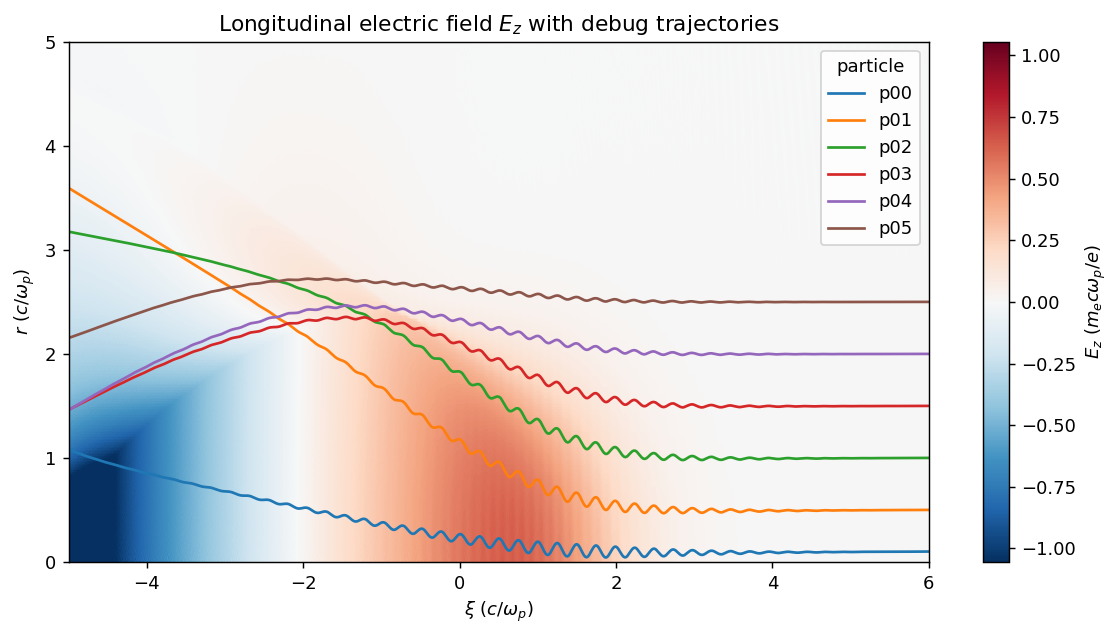

In [30]:
# Longitudinal electric field with the debug trajectory overlaid.
# E1_M0 lives on (xiaxis_1, raxis_2).
plot_field_with_debug_trajectories(
    sim.xiaxis_1,
    sim.raxis_2,
    sim.E1_M0,
    debugs,
    title=r"Longitudinal electric field $E_z$ with debug trajectories",
    field_label=r"$E_z$ $(m_e c \omega_p/e)$",
    xlim=(-5, 6),
    # xlim=(-0.5, 0.5),
    ylim=(0, 5),
    # vmin=0.5,
    # vmax=0.7
)

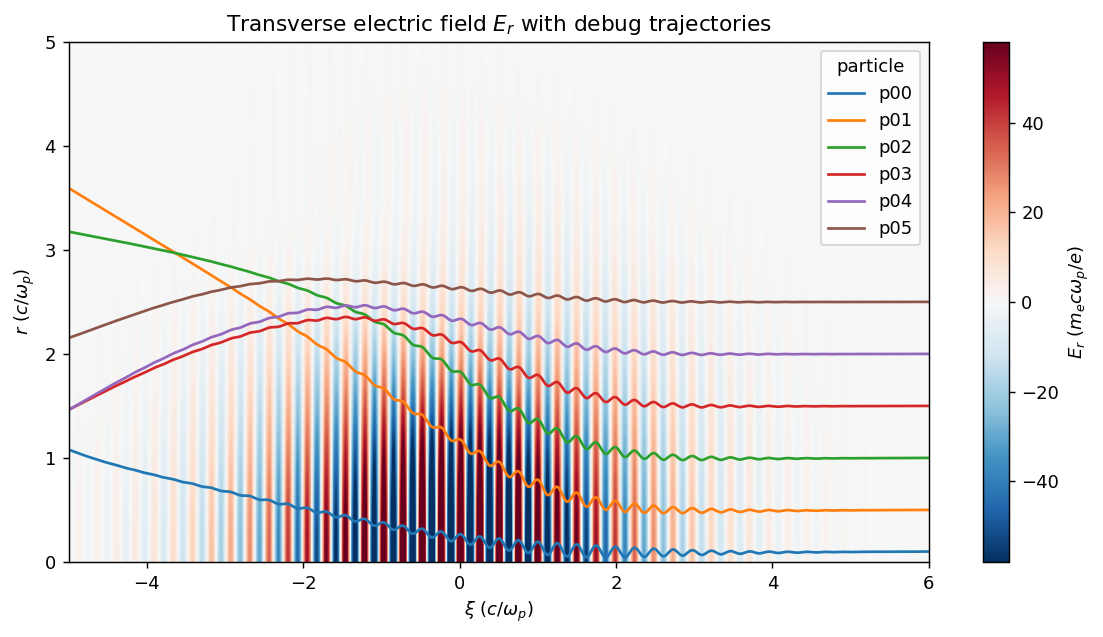

In [31]:
# Transverse/radial electric field with the debug trajectory overlaid.
# For mode 0 and phi = 0, E2_M0 corresponds to the radial/transverse field.
# E2_M0 lives on (xiaxis_2, raxis_1).
plot_field_with_debug_trajectories(
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M1_Re,
    debugs,
    title=r"Transverse electric field $E_r$ with debug trajectories",
    field_label=r"$E_r$ $(m_e c \omega_p/e)$",
    xlim=(-5, 6),
    ylim=(0, 5),
)

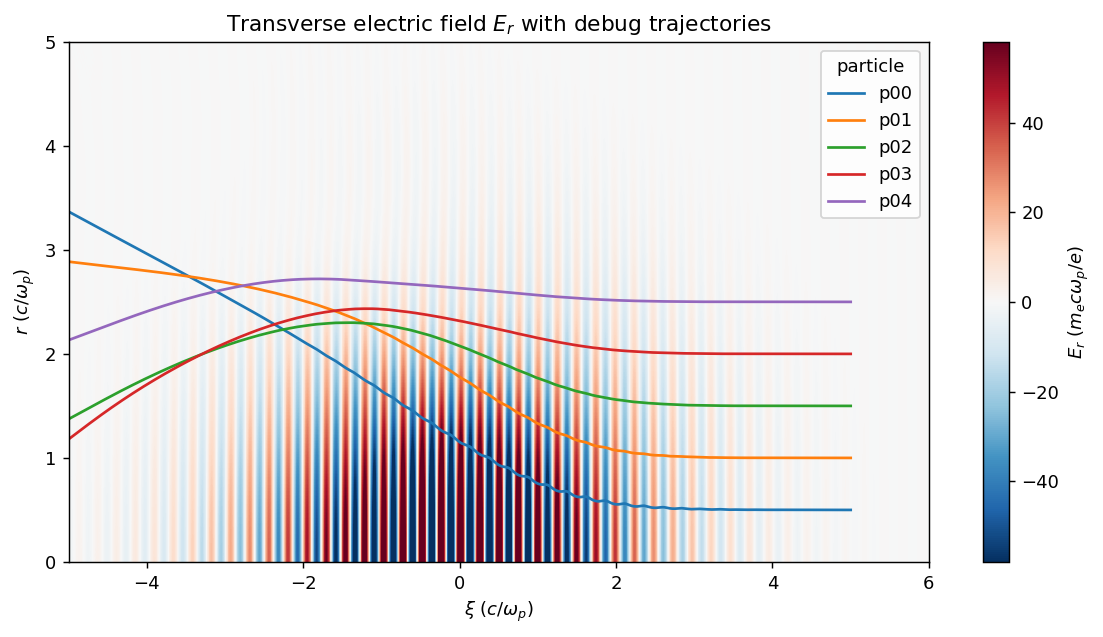

In [6]:
# Transverse/radial electric field with the debug trajectory overlaid.
# For mode 0 and phi = 0, E2_M0 corresponds to the radial/transverse field.
# E2_M0 lives on (xiaxis_2, raxis_1).
plot_field_with_debug_trajectories(
    sim.xiaxis_2,
    sim.raxis_1,
    sim.E2_M1_Re,
    debugs,
    title=r"Transverse electric field $E_r$ with debug trajectories",
    field_label=r"$E_r$ $(m_e c \omega_p/e)$",
    xlim=(-5, 6),
    ylim=(0, 5),
)

In [11]:
# Defining functions that allow fields and debug trajectories to be called as needed.

def as_2d(arr):
    """Return an array with shape (n_particles, n_steps)."""
    arr = np.asarray(arr)
    if arr.ndim == 1:
        return arr[None, :]
    return arr


def get_debug_quantity(debug, quantity):
    """
    Extract a trajectory quantity from one DebugObject.

    quantity can be:
        - "xi_dat", "x_dat", "y_dat", "Fx_dat", "Fy_dat", etc.
        - "r_dat" for sqrt(x_dat^2 + y_dat^2)
        - a function, e.g. lambda debug: debug.Fx_dat + debug.Fy_dat
    """
    #callable is used to return a custom variable defined by a function
    if callable(quantity):
        return as_2d(quantity(debug))

    if quantity == "r_dat":
        x_dat = as_2d(debug.x_dat)
        y_dat = as_2d(debug.y_dat)
        return np.sqrt(x_dat**2 + y_dat**2)

    if not hasattr(debug, quantity):
        raise AttributeError(f"Debug object does not have attribute '{quantity}'.")

    return as_2d(getattr(debug, quantity))


def symmetric_color_limits(field, percentile=99):
    """Choose symmetric color limits using a percentile to avoid outlier domination."""
    vmax = np.nanpercentile(np.abs(field), percentile)
    return -vmax, vmax


def plot_field_with_debug_trajectories(
    xi_axis=None,
    y_axis=None,
    field=None,
    debug_objects=None,
    *,
    trajectory_quantity="r_dat",
    trajectory_label=None,
    xi_quantity="xi_dat",
    title,
    field_label=None,
    xlim=None,
    ylim=None,
    vmin=None,
    vmax=None,
    cmap="RdBu_r",
    show_field=True,
):
    """
    Plot debug trajectories versus xi.

    If field, xi_axis, and y_axis are provided and show_field=True,
    the function also plots the field as a background pcolormesh.

    trajectory_quantity can be:
        "r_dat"
        "x_dat"
        "y_dat"
        "Fx_dat"
        "Fy_dat"
        or a custom function, e.g.
        lambda debug: debug.Fx_dat + debug.Fy_dat
    Setting show_field as false allows you to plot without the field. 
    """

    if debug_objects is None:
        raise ValueError("debug_objects must be provided.")

    if not isinstance(debug_objects, (list, tuple)):
        debug_objects = [debug_objects]

    fig, ax = plt.subplots(figsize=(9, 5), dpi=130)

    plot_background_field = (
        show_field
        and field is not None
        and xi_axis is not None
        and y_axis is not None
    )

    if plot_background_field:
        if vmin is None or vmax is None:
            auto_vmin, auto_vmax = symmetric_color_limits(field)
            vmin = auto_vmin if vmin is None else vmin
            vmax = auto_vmax if vmax is None else vmax

        mesh = ax.pcolormesh(
            xi_axis,
            y_axis,
            field,
            shading="auto",
            cmap=cmap,
            vmin=vmin,
            vmax=vmax,
        )

        cbar = fig.colorbar(mesh, ax=ax)
        if field_label is not None:
            cbar.set_label(field_label)

    for debug in debug_objects:
        xi_dat = get_debug_quantity(debug, xi_quantity)
        y_dat = get_debug_quantity(debug, trajectory_quantity)

        tag = getattr(debug, "tag", None)

        for i in range(y_dat.shape[0]):
            label = tag if i == 0 else None
            ax.plot(
                xi_dat[i, :],
                y_dat[i, :],
                linewidth=1.5,
                label=label,
            )

    ax.set_xlabel(r"$\xi$ $(c/\omega_p)$")

    if trajectory_label is not None:
        ax.set_ylabel(trajectory_label)
    elif isinstance(trajectory_quantity, str):
        ax.set_ylabel(trajectory_quantity)
    else:
        ax.set_ylabel("trajectory quantity")

    ax.set_title(title)

    if xlim is not None:
        ax.set_xlim(*xlim)
    if ylim is not None:
        ax.set_ylim(*ylim)

    if len(debug_objects) > 0:
        ax.legend(loc="best", title="particle")

    fig.tight_layout()
    plt.show()

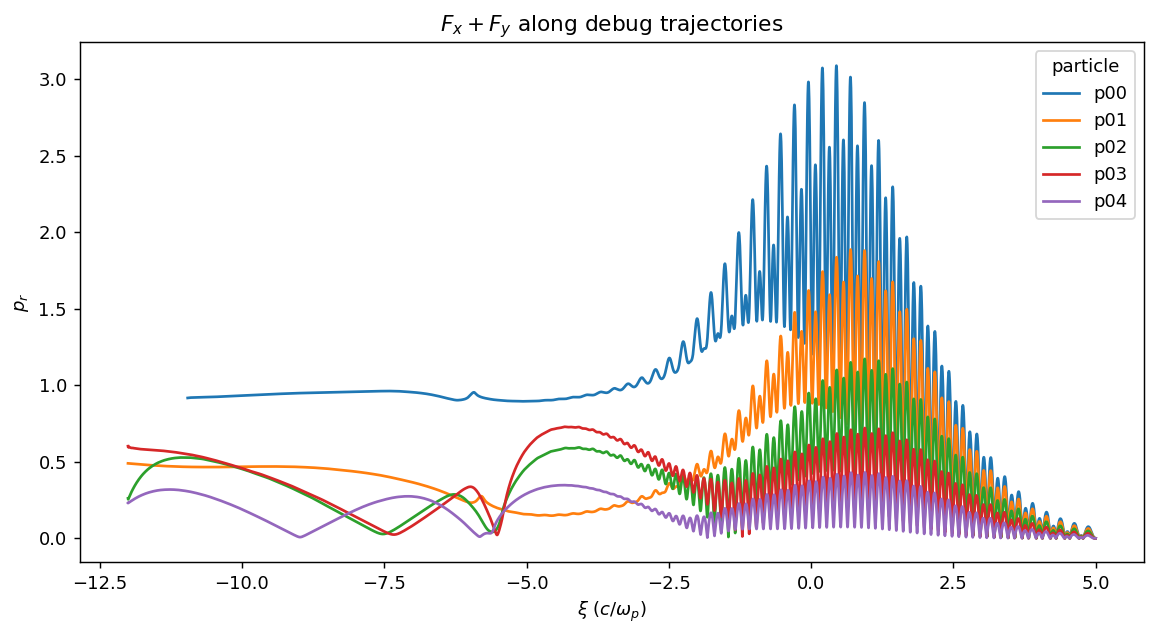

In [14]:
plot_field_with_debug_trajectories(
    debug_objects=debugs,
    #lambda is a short hand for unnamed function in python means take debug and 
    #return the expression after ':'
    # trajectory_quantity=lambda debug: np.sqrt(debug.Fx_dat**2 + debug.Fy_dat**2),
    trajectory_quantity=lambda debug: np.sqrt(debug.px_dat**2 + debug.py_dat**2),
    trajectory_label=r"$p_r$",
    title=r"$F_x + F_y$ along debug trajectories",
    show_field=False,
)